In [1]:
# ============================================================
# CELL 1: SETUP
# ============================================================
!pip install yfinance --quiet

import requests
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ============================================================
# CELL 2: COMPANY SELECTION & CIK LOOKUP
# ============================================================
HEADERS = {
    'User-Agent': 'Denesh Kandasamy denesh0508@gmail.com'
}

COMPANIES = {
    'Apple':     'AAPL',
    'Microsoft': 'MSFT',
    'Tesla':     'TSLA',
    'Boeing':    'BA',
    'Macys':     'M',
}

def get_cik_lookup():
    url = 'https://www.sec.gov/files/company_tickers.json'
    response = requests.get(url, headers=HEADERS)
    data = response.json()
    cik_map = {}
    for entry in data.values():
        ticker = entry['ticker'].upper()
        cik = str(entry['cik_str']).zfill(10)
        cik_map[ticker] = cik
    return cik_map

cik_lookup = get_cik_lookup()

company_ciks = {}
for name, ticker in COMPANIES.items():
    cik = cik_lookup.get(ticker.upper())
    if cik:
        company_ciks[name] = {'ticker': ticker, 'cik': cik}
        print(f"{name} ({ticker}): CIK = {cik}")
    else:
        print(f"WARNING: Could not find CIK for {ticker}")

Apple (AAPL): CIK = 0000320193
Microsoft (MSFT): CIK = 0000789019
Tesla (TSLA): CIK = 0001318605
Boeing (BA): CIK = 0000012927
Macys (M): CIK = 0000794367


In [3]:
# ============================================================
# CELL 3: SEC EDGAR DATA EXTRACTION (FIXED — ALL REVENUE TAGS)
# ============================================================
def fetch_company_facts(cik):
    url = f'https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json'
    response = requests.get(url, headers=HEADERS)
    if response.status_code != 200:
        raise ValueError(f"Failed to fetch data for CIK {cik}: HTTP {response.status_code}")
    return response.json()

def extract_annual_series(facts, tag, unit='USD'):
    try:
        entries = facts['facts']['us-gaap'][tag]['units'][unit]
    except KeyError:
        return {}
    annual_data = {}
    for entry in entries:
        if entry.get('form') == '10-K' and entry.get('fp') == 'FY':
            year = entry.get('fy')
            value = entry.get('val')
            if year and value is not None:
                if year not in annual_data:
                    annual_data[year] = value
    return annual_data

def try_tags(facts, tag_options, unit='USD'):
    for tag in tag_options:
        result = extract_annual_series(facts, tag, unit)
        if result:
            return result
    return {}

def extract_financials(facts):
    data = {}
    data['total_assets'] = try_tags(facts, [
        'Assets'
    ])
    data['total_liabilities'] = try_tags(facts, [
        'Liabilities',
        'LiabilitiesAndStockholdersEquity'
    ])
    data['current_assets'] = try_tags(facts, [
        'AssetsCurrent'
    ])
    data['current_liabilities'] = try_tags(facts, [
        'LiabilitiesCurrent'
    ])
    data['retained_earnings'] = try_tags(facts, [
        'RetainedEarningsAccumulatedDeficit',
        'RetainedEarnings'
    ])
    data['stockholders_equity'] = try_tags(facts, [
        'StockholdersEquity',
        'StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest'
    ])
    data['revenue'] = try_tags(facts, [
        'RevenueFromContractWithCustomerExcludingAssessedTax',
        'RevenueFromContractWithCustomerIncludingAssessedTax',
        'Revenues',
        'SalesRevenueNet',
        'SalesRevenueGoodsNet',
        'SalesRevenueServicesNet',
        'RevenuesNetOfInterestExpense',
        'RevenueNotFromContractWithCustomer',
        'RevenueFromContractWithCustomer'
    ])
    data['ebit'] = try_tags(facts, [
        'OperatingIncomeLoss',
        'IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest',
        'IncomeLossFromContinuingOperationsBeforeIncomeTaxesMinorityInterestAndIncomeLossFromEquityMethodInvestments'
    ])
    data['net_income'] = try_tags(facts, [
        'NetIncomeLoss',
        'ProfitLoss',
        'NetIncomeLossAvailableToCommonStockholdersBasic'
    ])
    data['gross_profit'] = try_tags(facts, [
        'GrossProfit'
    ])
    return data

all_financials = {}

for company, info in company_ciks.items():
    print(f"Fetching data for {company}...")
    try:
        facts = fetch_company_facts(info['cik'])
        all_financials[company] = extract_financials(facts)
        rev_years = len(all_financials[company].get('revenue', {}))
        print(f"  Done — revenue years found: {rev_years}")
    except Exception as e:
        print(f"  Error: {e}")
    time.sleep(0.5)

print("\nData extraction complete.")

Fetching data for Apple...
  Done — revenue years found: 7
Fetching data for Microsoft...
  Done — revenue years found: 8
Fetching data for Tesla...
  Done — revenue years found: 4
Fetching data for Boeing...
  Done — revenue years found: 1
Fetching data for Macys...
  Done — revenue years found: 8

Data extraction complete.


In [4]:
# ============================================================
# CELL 4: MARKET DATA FROM YAHOO FINANCE
# ============================================================
def get_market_cap_history(ticker, years):
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        market_cap = info.get('marketCap', None)
        if market_cap:
            return {year: market_cap for year in years}
        else:
            return {}
    except Exception as e:
        print(f"Could not fetch market cap for {ticker}: {e}")
        return {}

years_needed = list(range(2019, 2025))
market_caps = {}

for company, info in company_ciks.items():
    market_caps[company] = get_market_cap_history(info['ticker'], years_needed)
    print(f"Market cap fetched for {company}")
    time.sleep(0.3)

print("\nMarket data collection complete.")

Market cap fetched for Apple
Market cap fetched for Microsoft
Market cap fetched for Tesla
Market cap fetched for Boeing
Market cap fetched for Macys

Market data collection complete.


In [5]:
# ============================================================
# CELL 5: ALTMAN Z-SCORE CALCULATION (FIXED)
# ============================================================
def compute_zscore(financials, market_cap, years):
    """
    Computes Altman Z-Score components and total score for each fiscal year.
    Z = 1.2(X1) + 1.4(X2) + 3.3(X3) + 0.6(X4) + 1.0(X5)
    X1 = Working Capital / Total Assets        (liquidity)
    X2 = Retained Earnings / Total Assets      (cumulative profitability)
    X3 = EBIT / Total Assets                   (operating efficiency)
    X4 = Market Value of Equity / Total Liab   (solvency)
    X5 = Revenue / Total Assets                (asset turnover)
    """
    results = []
    for year in years:
        try:
            total_assets        = financials['total_assets'].get(year)
            total_liabilities   = financials['total_liabilities'].get(year)
            current_assets      = financials['current_assets'].get(year)
            current_liabilities = financials['current_liabilities'].get(year)
            retained_earnings   = financials['retained_earnings'].get(year)
            revenue             = financials['revenue'].get(year)
            ebit                = financials['ebit'].get(year)
            mve                 = market_cap.get(year)
            # Fallback 1: derive liabilities from assets minus equity
            if total_liabilities is None:
                equity = financials['stockholders_equity'].get(year)
                if total_assets is not None and equity is not None:
                    total_liabilities = total_assets - equity
            # Fallback 2: if retained earnings missing, use net income as proxy
            if retained_earnings is None:
                retained_earnings = financials['net_income'].get(year)
            # Fallback 3: if current items missing, set working capital to 0
            if current_assets is None or current_liabilities is None:
                working_capital = 0
            else:
                working_capital = current_assets - current_liabilities
            # Skip year if critical values are still missing
            if None in [total_assets, total_liabilities, revenue, ebit, mve]:
                continue
            if total_assets == 0:
                continue
            # Use 0 for retained earnings if all fallbacks failed
            if retained_earnings is None:
                retained_earnings = 0
            # Compute Z-Score components
            x1 = working_capital / total_assets
            x2 = retained_earnings / total_assets
            x3 = ebit / total_assets
            x4 = mve / total_liabilities if total_liabilities != 0 else np.nan
            x5 = revenue / total_assets
            z_score = 1.2*x1 + 1.4*x2 + 3.3*x3 + 0.6*x4 + 1.0*x5
            if z_score > 2.99:
                zone = 'Safe'
            elif z_score > 1.81:
                zone = 'Grey'
            else:
                zone = 'Distress'
            results.append({
                'Year': year,
                'X1 (Liquidity)': round(x1, 4),
                'X2 (Retained Earnings)': round(x2, 4),
                'X3 (Profitability)': round(x3, 4),
                'X4 (Leverage)': round(x4, 4),
                'X5 (Asset Turnover)': round(x5, 4),
                'Z-Score': round(z_score, 4),
                'Zone': zone
            })
        except Exception:
            continue
    return pd.DataFrame(results).set_index('Year') if results else pd.DataFrame()

zscore_results = {}
for company, info in company_ciks.items():
    financials = all_financials.get(company, {})
    mkt_cap = market_caps.get(company, {})
    df = compute_zscore(financials, mkt_cap, years_needed)
    if not df.empty:
        zscore_results[company] = df
        print(f"{company} Z-Scores computed: {len(df)} years")
    else:
        print(f"{company}: insufficient data")

print("\nZ-Score computation complete.")

Apple Z-Scores computed: 6 years
Microsoft Z-Scores computed: 6 years
Tesla Z-Scores computed: 2 years
Boeing Z-Scores computed: 1 years
Macys Z-Scores computed: 6 years

Z-Score computation complete.


In [6]:
# ============================================================
# CELL 6: DUPONT ROE DECOMPOSITION (FIXED)
# ============================================================
def compute_dupont(financials, years):
    """
    Computes DuPont ROE decomposition for each fiscal year.
    ROE = Net Profit Margin x Asset Turnover x Equity Multiplier
        = (Net Income / Revenue) x (Revenue / Assets) x (Assets / Equity)
    """
    results = []
    for year in years:
        try:
            net_income    = financials['net_income'].get(year)
            revenue       = financials['revenue'].get(year)
            total_assets  = financials['total_assets'].get(year)
            equity        = financials['stockholders_equity'].get(year)
            # Fallback: derive equity from assets minus liabilities
            if equity is None:
                total_liabilities = financials['total_liabilities'].get(year)
                if total_assets is not None and total_liabilities is not None:
                    equity = total_assets - total_liabilities
            if None in [net_income, revenue, total_assets, equity]:
                continue
            if revenue == 0 or total_assets == 0 or equity == 0:
                continue
            net_margin        = net_income / revenue
            asset_turnover    = revenue / total_assets
            equity_multiplier = total_assets / equity
            roe               = net_margin * asset_turnover * equity_multiplier
            results.append({
                'Year': year,
                'Net Margin': round(net_margin, 4),
                'Asset Turnover': round(asset_turnover, 4),
                'Equity Multiplier': round(equity_multiplier, 4),
                'ROE': round(roe, 4)
            })
        except Exception:
            continue
    return pd.DataFrame(results).set_index('Year') if results else pd.DataFrame()

dupont_results = {}
for company, info in company_ciks.items():
    financials = all_financials.get(company, {})
    df = compute_dupont(financials, years_needed)
    if not df.empty:
        dupont_results[company] = df
        print(f"{company} DuPont computed: {len(df)} years")
    else:
        print(f"{company}: insufficient data")

Apple DuPont computed: 6 years
Microsoft DuPont computed: 6 years
Tesla DuPont computed: 2 years
Boeing DuPont computed: 1 years
Macys DuPont computed: 5 years


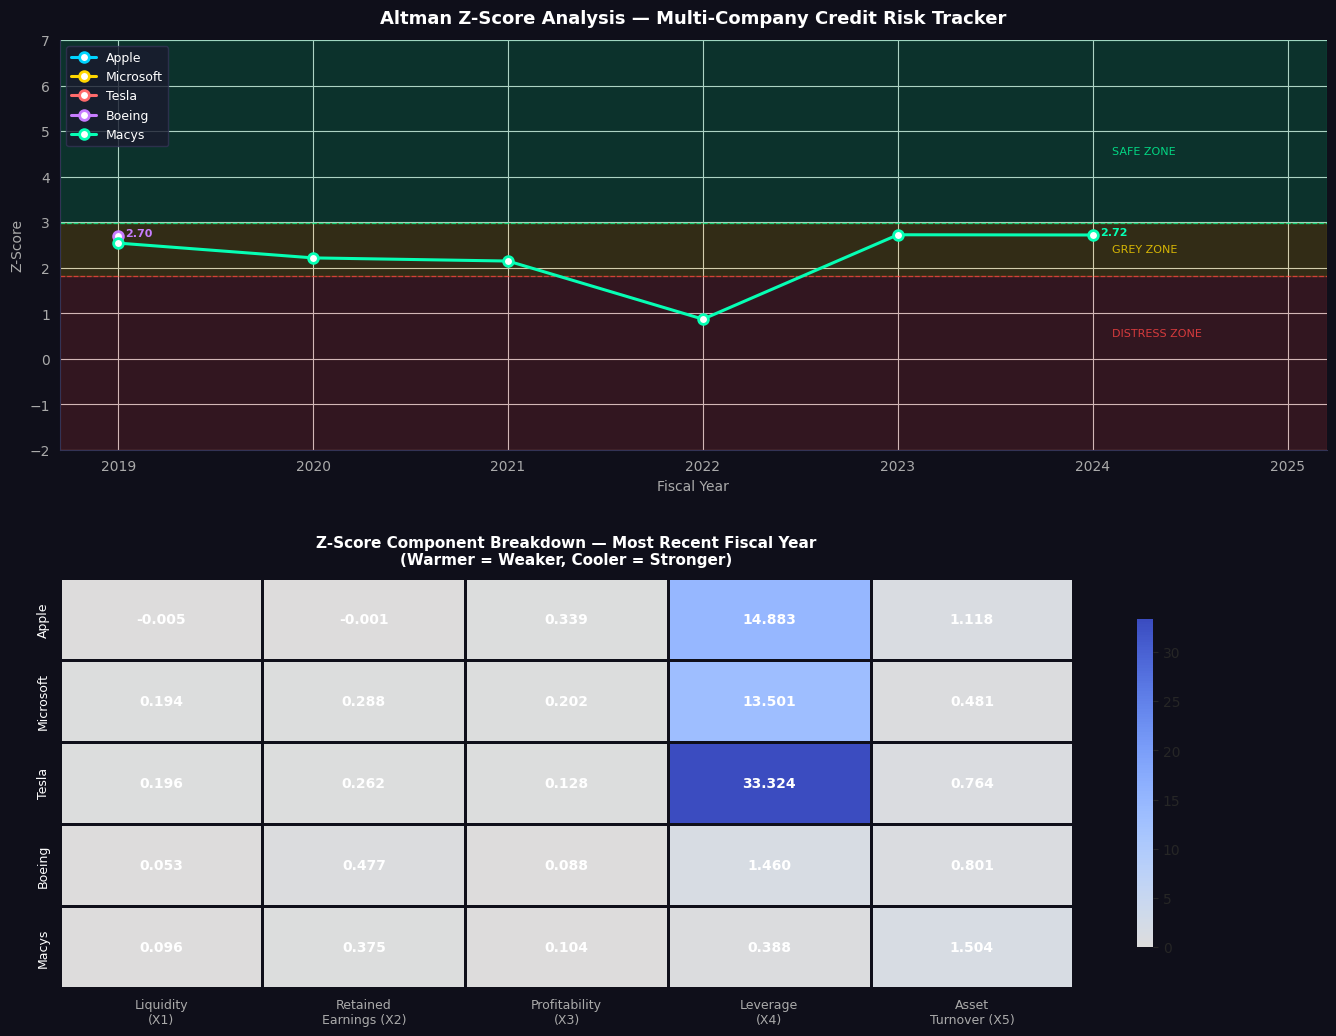

Z-Score dashboard saved.


In [7]:
# ============================================================
# CELL 7: Z-SCORE VISUALISATION DASHBOARD (DISTINCTIVE STYLE)
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.patch.set_facecolor('#0F0F1A')

ax1 = axes[0]
ax1.set_facecolor('#0F0F1A')
ax1.axhspan(2.99, 7,    alpha=0.15, color='#00FF99')
ax1.axhspan(1.81, 2.99, alpha=0.15, color='#FFD700')
ax1.axhspan(-2,   1.81, alpha=0.15, color='#FF4444')
ax1.axhline(2.99, color='#00FF99', linestyle='--', linewidth=0.9, alpha=0.7)
ax1.axhline(1.81, color='#FF4444', linestyle='--', linewidth=0.9, alpha=0.7)
ax1.text(years_needed[-1] + 0.1, 4.5,  'SAFE ZONE',     color='#00FF99', fontsize=8, alpha=0.8)
ax1.text(years_needed[-1] + 0.1, 2.35, 'GREY ZONE',     color='#FFD700', fontsize=8, alpha=0.8)
ax1.text(years_needed[-1] + 0.1, 0.5,  'DISTRESS ZONE', color='#FF4444', fontsize=8, alpha=0.8)

line_colors = ['#00D4FF', '#FFD700', '#FF6B6B', '#C77DFF', '#06FFB4']
for (company, df), color in zip(zscore_results.items(), line_colors):
    if not df.empty:
        ax1.plot(df.index, df['Z-Score'],
                 marker='o', linewidth=2.2, markersize=7,
                 label=company, color=color,
                 markerfacecolor='white', markeredgecolor=color, markeredgewidth=2)
        last_year = df.index[-1]
        last_val = df['Z-Score'].iloc[-1]
        ax1.annotate(f'{last_val:.2f}',
                     xy=(last_year, last_val),
                     xytext=(5, 0), textcoords='offset points',
                     color=color, fontsize=8, fontweight='bold')

ax1.set_title('Altman Z-Score Analysis — Multi-Company Credit Risk Tracker',
              fontsize=13, fontweight='bold', color='white', pad=12)
ax1.set_ylabel('Z-Score', color='#AAAAAA')
ax1.set_xlabel('Fiscal Year', color='#AAAAAA')
ax1.tick_params(colors='#AAAAAA')
ax1.spines['bottom'].set_color('#333355')
ax1.spines['left'].set_color('#333355')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(-2, 7)
ax1.set_xlim(years_needed[0] - 0.3, years_needed[-1] + 1.2)
ax1.legend(loc='upper left', fontsize=9,
           facecolor='#1A1A2E', edgecolor='#333355',
           labelcolor='white')

ax2 = axes[1]
ax2.set_facecolor('#0F0F1A')
component_cols = [
    'X1 (Liquidity)', 'X2 (Retained Earnings)',
    'X3 (Profitability)', 'X4 (Leverage)', 'X5 (Asset Turnover)'
]
heatmap_data = {}
for company, df in zscore_results.items():
    if not df.empty:
        latest = df.iloc[-1]
        heatmap_data[company] = latest[component_cols]

if heatmap_data:
    heatmap_df = pd.DataFrame(heatmap_data).T
    heatmap_df.columns = [
        'Liquidity\n(X1)', 'Retained\nEarnings (X2)',
        'Profitability\n(X3)', 'Leverage\n(X4)', 'Asset\nTurnover (X5)'
    ]
    sns.heatmap(
        heatmap_df.astype(float),
        annot=True, fmt='.3f',
        cmap='coolwarm_r',
        center=0,
        ax=ax2,
        linewidths=1,
        linecolor='#0F0F1A',
        annot_kws={'size': 10, 'weight': 'bold', 'color': 'white'},
        cbar_kws={'shrink': 0.8}
    )
    ax2.set_title(
        'Z-Score Component Breakdown — Most Recent Fiscal Year\n(Warmer = Weaker, Cooler = Stronger)',
        fontsize=11, fontweight='bold', color='white', pad=10
    )
    ax2.tick_params(colors='#AAAAAA', labelsize=9)
    ax2.set_yticklabels(ax2.get_yticklabels(), color='white', fontsize=9)
    ax2.set_xticklabels(ax2.get_xticklabels(), color='#AAAAAA', fontsize=9)

plt.tight_layout(pad=3)
plt.savefig('zscore_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0F0F1A')
plt.show()
print("Z-Score dashboard saved.")

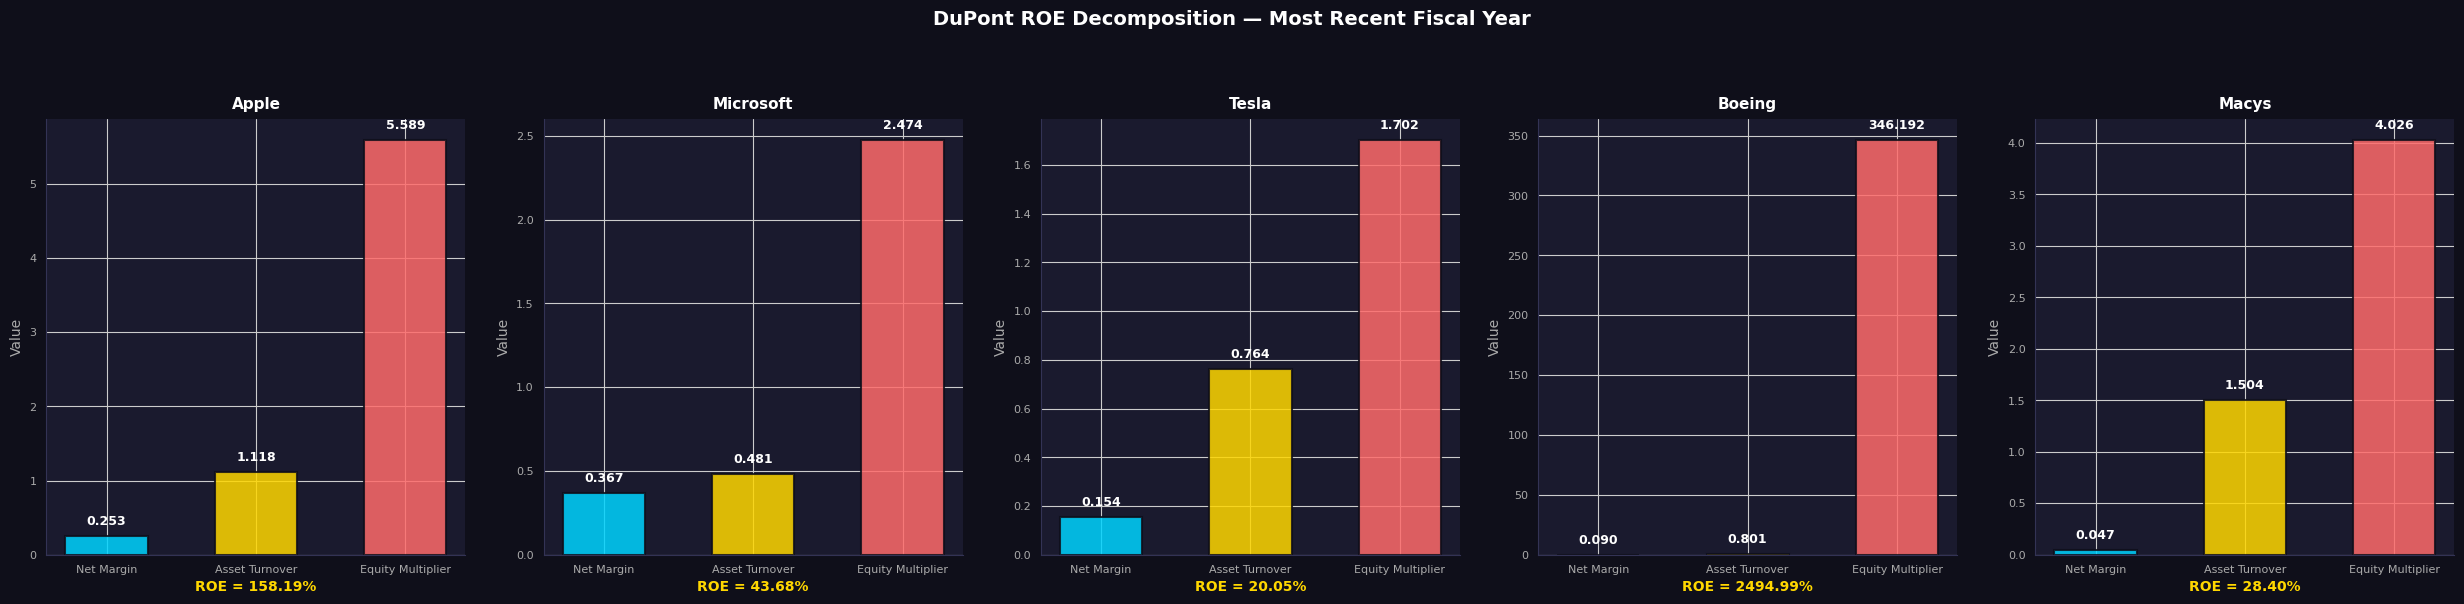

DuPont dashboard saved.


In [8]:
# ============================================================
# CELL 8: DUPONT DECOMPOSITION VISUALISATION (DISTINCTIVE STYLE)
# ============================================================
companies_with_data = [c for c, df in dupont_results.items() if not df.empty]
n = len(companies_with_data)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5*n, 6), sharey=False)
    fig.patch.set_facecolor('#0F0F1A')
    if n == 1:
        axes = [axes]

    bar_colors = ['#00D4FF', '#FFD700', '#FF6B6B']
    bar_labels  = ['Net Margin', 'Asset Turnover', 'Equity Multiplier']

    for ax, company in zip(axes, companies_with_data):
        ax.set_facecolor('#1A1A2E')
        df = dupont_results[company]
        latest = df.iloc[-1]
        values = [latest['Net Margin'], latest['Asset Turnover'], latest['Equity Multiplier']]
        bars = ax.bar(bar_labels, values, color=bar_colors,
                      alpha=0.85, edgecolor='#0F0F1A', linewidth=1.5,
                      width=0.55)
        for bar, val in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.02,
                f'{val:.3f}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='white'
            )
        ax.set_title(f'{company}', fontsize=11, fontweight='bold',
                     color='white', pad=8)
        ax.set_xlabel(f'ROE = {latest["ROE"]:.2%}', color='#FFD700',
                      fontsize=10, fontweight='bold')
        ax.set_ylabel('Value', color='#AAAAAA')
        ax.tick_params(colors='#AAAAAA', labelsize=8)
        ax.spines['bottom'].set_color('#333355')
        ax.spines['left'].set_color('#333355')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xticklabels(bar_labels, color='#AAAAAA', fontsize=8)

    fig.suptitle('DuPont ROE Decomposition — Most Recent Fiscal Year',
                 fontsize=14, fontweight='bold', color='white', y=1.02)
    plt.tight_layout(pad=2)
    plt.savefig('dupont_dashboard.png', dpi=150, bbox_inches='tight',
                facecolor='#0F0F1A')
    plt.show()
    print("DuPont dashboard saved.")

In [9]:
# ============================================================
# CELL 9: CREDIT SUMMARY REPORT
# ============================================================
summary_rows = []

for company in company_ciks.keys():
    zscore_df = zscore_results.get(company, pd.DataFrame())
    dupont_df = dupont_results.get(company, pd.DataFrame())
    if zscore_df.empty:
        continue
    latest_z    = zscore_df.iloc[-1]
    latest_year = zscore_df.index[-1]
    row = {
        'Company': company,
        'Year': latest_year,
        'Z-Score': f"{latest_z['Z-Score']:.2f}",
        'Zone': latest_z['Zone'],
        'YoY Change': ''
    }
    if len(zscore_df) >= 2:
        prev_z = zscore_df.iloc[-2]['Z-Score']
        change = latest_z['Z-Score'] - prev_z
        direction = 'up' if change > 0 else 'dn'
        row['YoY Change'] = f"{direction} {abs(change):.2f}"
    if not dupont_df.empty:
        latest_d = dupont_df.iloc[-1]
        row['ROE']               = f"{latest_d['ROE']:.2%}"
        row['Net Margin']        = f"{latest_d['Net Margin']:.2%}"
        row['Asset Turnover']    = f"{latest_d['Asset Turnover']:.2f}x"
        row['Equity Multiplier'] = f"{latest_d['Equity Multiplier']:.2f}x"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

print("=" * 80)
print("CREDIT ANALYSIS SUMMARY REPORT")
print("Altman Z-Score and DuPont ROE Decomposition")
print("Data Source: SEC EDGAR XBRL Filings + Yahoo Finance")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)
print("\nZ-Score Zones:")
print("  Safe Zone     : Z > 2.99  — Financially healthy")
print("  Grey Zone     : 1.81-2.99 — Monitor carefully")
print("  Distress Zone : Z < 1.81  — High bankruptcy risk")

CREDIT ANALYSIS SUMMARY REPORT
Altman Z-Score and DuPont ROE Decomposition
Data Source: SEC EDGAR XBRL Filings + Yahoo Finance
  Company  Year Z-Score Zone YoY Change      ROE Net Margin Asset Turnover Equity Multiplier
    Apple  2024   11.16 Safe    up 0.59  158.19%     25.31%          1.12x             5.59x
Microsoft  2024    9.89 Safe    dn 0.18   43.68%     36.69%          0.48x             2.47x
    Tesla  2024   21.78 Safe    dn 3.16   20.05%     15.41%          0.76x             1.70x
   Boeing  2019    2.70 Grey            2494.99%      9.00%          0.80x           346.19x
    Macys  2024    2.72 Grey    dn 0.01   28.40%      4.69%          1.50x             4.03x

Z-Score Zones:
  Safe Zone     : Z > 2.99  — Financially healthy
  Grey Zone     : 1.81-2.99 — Monitor carefully
  Distress Zone : Z < 1.81  — High bankruptcy risk


In [10]:
# ============================================================
# CELL 10: SAVE OUTPUTS AND GITHUB PREP
# ============================================================
summary_df.to_csv('credit_summary_report.csv', index=False)

print("Files saved:")
print("  zscore_dashboard.png      — Z-Score trends + component heatmap")
print("  dupont_dashboard.png      — DuPont ROE decomposition per company")
print("  credit_summary_report.csv — Full credit summary table")
print()
print("Next steps:")
print("  1. Download files via the Colab file browser (folder icon, left sidebar)")
print("  2. File > Download > Download .ipynb to save the notebook")
print("  3. Upload everything to your GitHub repo")
print("  4. Add this line to your README:")
print("     ![Z-Score Dashboard](zscore_dashboard.png)")

Files saved:
  zscore_dashboard.png      — Z-Score trends + component heatmap
  dupont_dashboard.png      — DuPont ROE decomposition per company
  credit_summary_report.csv — Full credit summary table

Next steps:
  1. Download files via the Colab file browser (folder icon, left sidebar)
  2. File > Download > Download .ipynb to save the notebook
  3. Upload everything to your GitHub repo
  4. Add this line to your README:
     ![Z-Score Dashboard](zscore_dashboard.png)
